# ONNX Model Testing — Rice Disease Detection
Run this notebook after training to evaluate your exported ONNX model.

In [1]:
# Cell 2 — Imports
import os
import numpy as np
import torch
import onnxruntime as ort
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torchvision import transforms
from tqdm.notebook import tqdm
import time

print('All imports successful')

All imports successful


In [2]:
# Cell 3 — Config
# Update these paths to match your setup
ONNX_MODEL_PATH = './rice_disease.onnx'
DATASET_PATH    = 'RiceDataset\\AugmentedDataset'

# Verify paths exist
print(f'Model exists: {os.path.exists(ONNX_MODEL_PATH)}')
print(f'Dataset exists: {os.path.exists(DATASET_PATH)}')

Model exists: True
Dataset exists: True


In [3]:
# Cell 4 — Load ONNX model
session = ort.InferenceSession(ONNX_MODEL_PATH)
input_name  = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

print(f'Input  name : {input_name}')
print(f'Input  shape: {session.get_inputs()[0].shape}')
print(f'Output name : {output_name}')
print(f'Output shape: {session.get_outputs()[0].shape}')

Input  name : input
Input  shape: ['batch_size', 3, 224, 224]
Output name : output
Output shape: ['batch_size', 8]


In [4]:
# Cell 5 — Load class names and build test file list
class_names = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print(f'Classes ({len(class_names)}):')
for idx, name in enumerate(class_names):
    print(f'  {idx}: {name}')

# Build full file list
image_paths, labels = [], []
for idx, class_name in enumerate(class_names):
    class_path = os.path.join(DATASET_PATH, class_name)
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    for img in images:
        image_paths.append(os.path.join(class_path, img))
        labels.append(idx)

print(f'\nTotal images: {len(image_paths)}')

Classes (8):
  0: Healthy
  1: Insect
  2: Leaf scald
  3: Rice Blast
  4: Rice Leaffolder
  5: Rice Stripes
  6: Rice Tungro
  7: rice

Total images: 18536


In [5]:
# Cell 6 — Use same test split as training (same random_state=42)
from sklearn.model_selection import train_test_split

_, temp_paths, _, temp_labels = train_test_split(
    image_paths, labels,
    test_size=0.3, stratify=labels, random_state=42
)
_, test_paths, _, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5, stratify=temp_labels, random_state=42
)

print(f'Test set size: {len(test_paths)} images')

Test set size: 2781 images


In [6]:
# Cell 7 — Preprocessing transform (must match training)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def preprocess(image_path):
    image = Image.open(image_path).convert('RGB')
    tensor = val_transform(image).unsqueeze(0).numpy()
    return image, tensor

def run_inference(tensor):
    outputs = session.run(
        [output_name], {input_name: tensor}
    )
    probs = torch.softmax(
        torch.tensor(outputs[0]), dim=1
    ).numpy()[0]
    return probs

print('Preprocessing ready')

Preprocessing ready


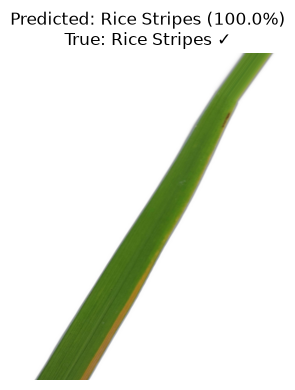


All probabilities:
  Rice Stripes         100.0% ███████████████████████████████████████
  Healthy                0.0% 
  Rice Tungro            0.0% 
  Insect                 0.0% 
  Rice Leaffolder        0.0% 
  Rice Blast             0.0% 
  Leaf scald             0.0% 
  rice                   0.0% 


('Rice Stripes', np.float32(99.99993))

In [7]:
# Cell 8 — Predict single image
def predict_single(image_path, true_label=None):
    image, tensor = preprocess(image_path)
    probs = run_inference(tensor)
    
    predicted_idx   = np.argmax(probs)
    predicted_class = class_names[predicted_idx]
    confidence      = probs[predicted_idx] * 100
    
    # Show image
    plt.figure(figsize=(5, 4))
    plt.imshow(image)
    title = f'Predicted: {predicted_class} ({confidence:.1f}%)'
    if true_label is not None:
        true_name = class_names[true_label]
        correct   = '✓' if predicted_idx == true_label else '✗'
        title    += f'\nTrue: {true_name} {correct}'
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Probability bars
    print('\nAll probabilities:')
    for name, prob in sorted(
        zip(class_names, probs),
        key=lambda x: x[1], reverse=True
    ):
        bar = '█' * int(prob * 40)
        print(f'  {name:20} {prob*100:5.1f}% {bar}')
    
    return predicted_class, confidence

# Test on first image in test set
predict_single(test_paths[0], test_labels[0])

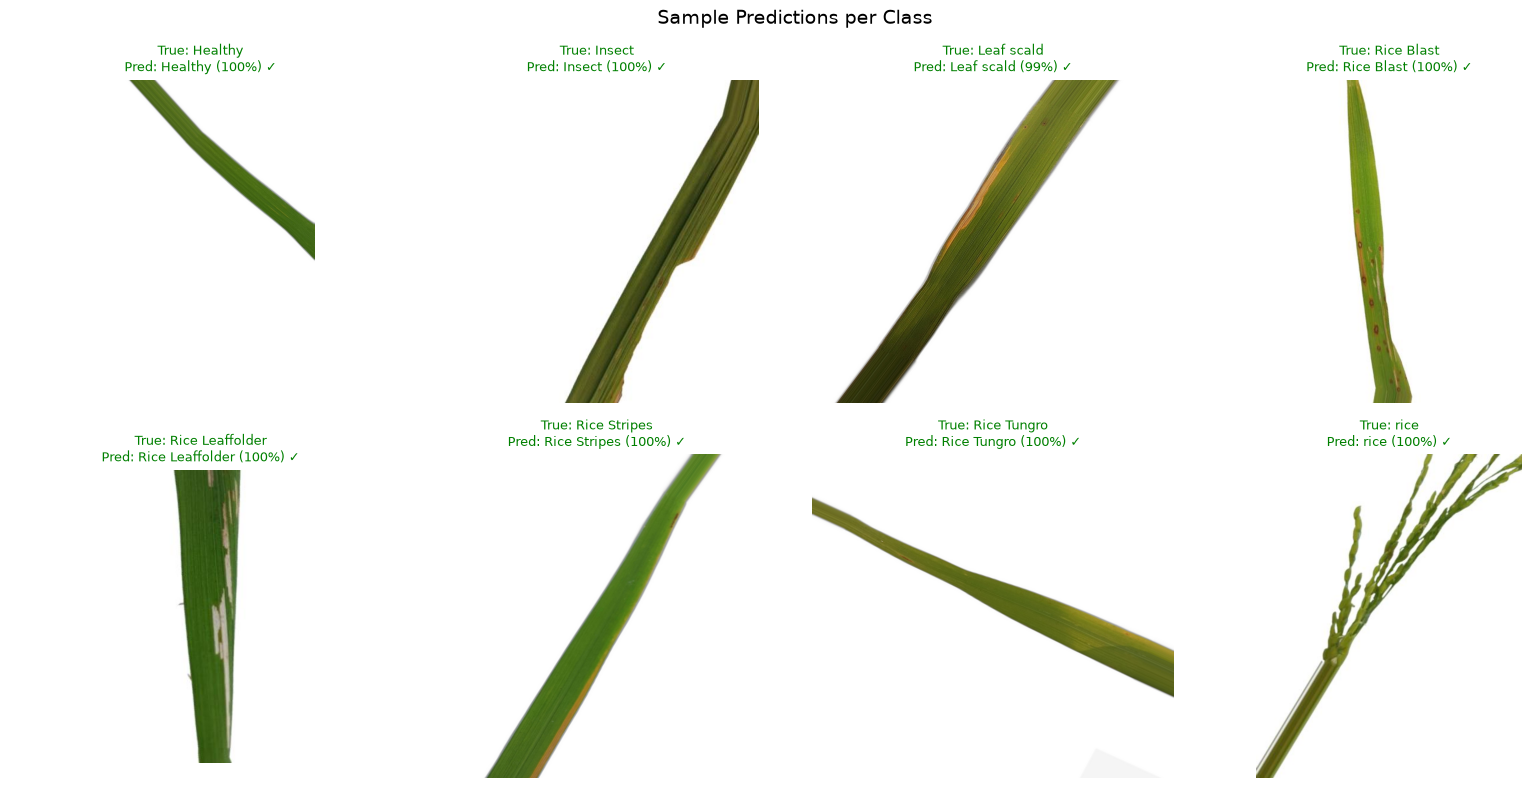

In [8]:
# Cell 9 — Test on sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, class_name in enumerate(class_names[:8]):
    # Get first test image of this class
    class_images = [
        p for p, l in zip(test_paths, test_labels)
        if l == idx
    ]
    if not class_images:
        continue
    
    image, tensor = preprocess(class_images[0])
    probs         = run_inference(tensor)
    predicted_idx = np.argmax(probs)
    confidence    = probs[predicted_idx] * 100
    correct       = predicted_idx == idx
    
    axes[idx].imshow(image)
    axes[idx].set_title(
        f'True: {class_name}\n'
        f'Pred: {class_names[predicted_idx]} '
        f'({confidence:.0f}%) '
        f'{"✓" if correct else "✗"}',
        fontsize=9,
        color='green' if correct else 'red'
    )
    axes[idx].axis('off')

plt.suptitle('Sample Predictions per Class', fontsize=14)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

In [9]:
# Cell 10 — Full test set accuracy
all_preds  = []
all_labels = []
correct    = 0

for img_path, true_label in tqdm(
    zip(test_paths, test_labels),
    total=len(test_paths),
    desc='Testing'
):
    _, tensor     = preprocess(img_path)
    probs         = run_inference(tensor)
    predicted_idx = int(np.argmax(probs))
    
    all_preds.append(predicted_idx)
    all_labels.append(true_label)
    if predicted_idx == true_label:
        correct += 1

overall_acc = 100. * correct / len(test_labels)
print(f'\nOverall Accuracy: {overall_acc:.2f}%')
print(f'Correct: {correct}/{len(test_labels)}')

Testing:   0%|          | 0/2781 [00:00<?, ?it/s]


Overall Accuracy: 98.42%
Correct: 2737/2781


In [10]:
# Cell 11 — Per class accuracy
print('Per-class accuracy:')
print('-' * 35)
for idx, class_name in enumerate(class_names):
    mask       = [l == idx for l in all_labels]
    class_pred = [all_preds[i] for i, m in enumerate(mask) if m]
    class_true = [all_labels[i] for i, m in enumerate(mask) if m]
    if class_true:
        acc = sum(
            p == t for p, t in zip(class_pred, class_true)
        ) / len(class_true)
        bar = '█' * int(acc * 30)
        print(f'  {class_name:20} {acc*100:5.1f}% {bar}')

Per-class accuracy:
-----------------------------------
  Healthy               99.8% █████████████████████████████
  Insect                97.8% █████████████████████████████
  Leaf scald            98.0% █████████████████████████████
  Rice Blast            98.8% █████████████████████████████
  Rice Leaffolder       98.0% █████████████████████████████
  Rice Stripes          96.7% █████████████████████████████
  Rice Tungro           97.8% █████████████████████████████
  rice                 100.0% ██████████████████████████████


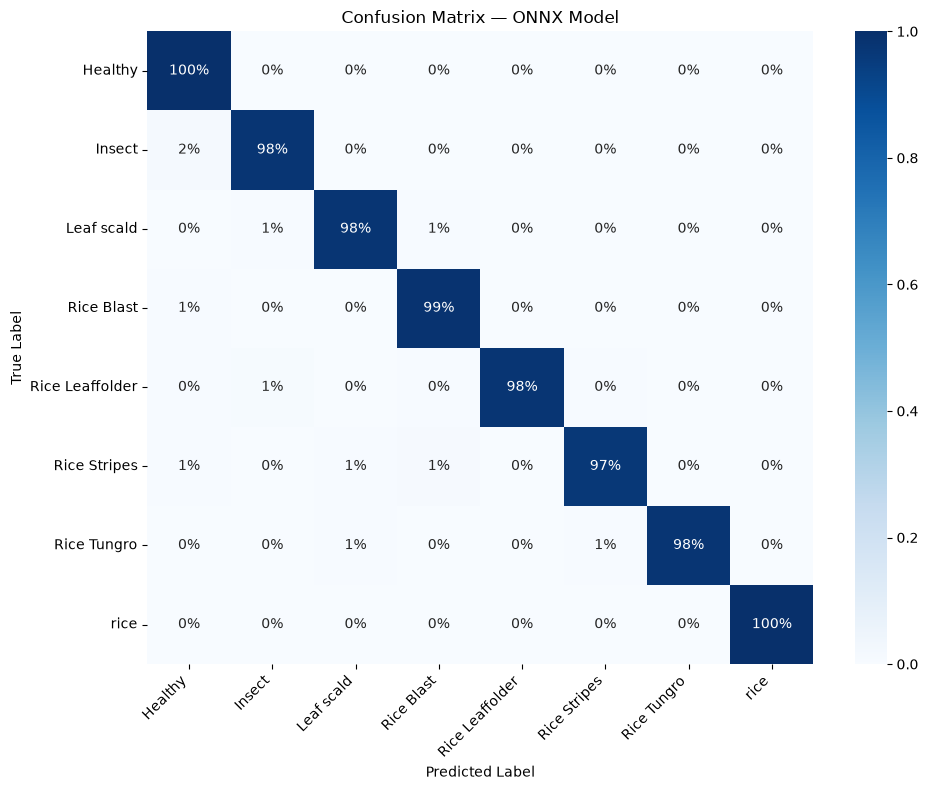

Saved to confusion_matrix.png


In [11]:
# Cell 12 — Confusion matrix
cm            = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.0%',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix — ONNX Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved to confusion_matrix.png')

In [12]:
# Cell 13 — Classification report
report = classification_report(
    all_labels, all_preds,
    target_names=class_names
)
print('Classification Report:')
print(report)

# Save report
with open('classification_report.txt', 'w') as f:
    f.write(report)
print('Saved to classification_report.txt')

Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.97      1.00      0.99       600
         Insect       0.99      0.98      0.98       313
     Leaf scald       0.99      0.98      0.98       393
     Rice Blast       0.99      0.99      0.99       668
Rice Leaffolder       1.00      0.98      0.99       248
   Rice Stripes       0.99      0.97      0.98       273
    Rice Tungro       0.98      0.98      0.98       267
           rice       1.00      1.00      1.00        19

       accuracy                           0.98      2781
      macro avg       0.99      0.98      0.99      2781
   weighted avg       0.98      0.98      0.98      2781

Saved to classification_report.txt


In [13]:
# Cell 14 — Benchmark inference speed
dummy = np.random.randn(1, 3, 224, 224).astype(np.float32)
times = []

# Warmup
for _ in range(10):
    session.run([output_name], {input_name: dummy})

# Measure
for _ in range(100):
    start = time.perf_counter()
    session.run([output_name], {input_name: dummy})
    times.append(time.perf_counter() - start)

avg_ms = np.mean(times) * 1000
std_ms = np.std(times) * 1000

print(f'Inference Speed:')
print(f'  Avg: {avg_ms:.2f}ms')
print(f'  Std: {std_ms:.2f}ms')
print(f'  FPS: {1000/avg_ms:.1f}')
print(f'  Min: {min(times)*1000:.2f}ms')
print(f'  Max: {max(times)*1000:.2f}ms')

Inference Speed:
  Avg: 2.27ms
  Std: 0.34ms
  FPS: 440.0
  Min: 1.65ms
  Max: 3.35ms


In [14]:
# Cell 15 — Summary
print('=' * 45)
print('ONNX MODEL TEST SUMMARY')
print('=' * 45)
print(f'Model:         {ONNX_MODEL_PATH}')
print(f'Test images:   {len(test_paths)}')
print(f'Classes:       {len(class_names)}')
print(f'Overall Acc:   {overall_acc:.2f}%')
print(f'Inference:     {avg_ms:.2f}ms ({1000/avg_ms:.1f} FPS)')
print('=' * 45)
print('Files saved:')
print('  confusion_matrix.png')
print('  sample_predictions.png')
print('  classification_report.txt')

ONNX MODEL TEST SUMMARY
Model:         ./rice_disease.onnx
Test images:   2781
Classes:       8
Overall Acc:   98.42%
Inference:     2.27ms (440.0 FPS)
Files saved:
  confusion_matrix.png
  sample_predictions.png
  classification_report.txt
